# 02 — Text Preprocessing
### IndicNews AI — Hindi News Analysis, Retrieval & Recommendation System

Builds and validates the reusable Hindi cleaning pipeline in
`training/preprocessing.py`, applied to **both** `Headline` and `Content`
per the project brief. Every stat below is computed against the real,
deduplicated dataset (34,826 unique articles — see 01_EDA §2.1 for why we
deduplicate first).

> Run from `training/notebooks/`. Uses `data_utils.py` and
> `preprocessing.py` (both one directory up).

In [7]:
pip uninstall indicnlp 

^C
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install indic-nlp-library nltk

In [23]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from data_utils import load_dataset
from preprocessing import (
    preprocess_text, preprocess_pipeline,
    normalize_unicode, remove_special_characters, remove_urls,
    tokenize, remove_stopwords, light_stem, HINDI_STOPWORDS,
)


import matplotlib.font_manager as fm

# Nirmala UI ships with Windows and covers Devanagari.
plt.rcParams["font.family"] = ["Nirmala UI", "DejaVu Sans"]


pd.set_option("display.max_colwidth", 120)
%matplotlib inline

In [ ]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from data_utils import load_dataset
from preprocessing import (
    preprocess_text, preprocess_pipeline,
    normalize_unicode, remove_special_characters, remove_urls,
    tokenize, remove_stopwords, light_stem, HINDI_STOPWORDS,
)



pd.set_option("display.max_colwidth", 120)
%matplotlib inline

## 1. Why IndicNLP, not NLTK, for Hindi

NLTK is in the brief's tech stack, but its tokenizers (Punkt) are tuned
for English/European sentence conventions, and — checked directly against
the installed corpus — its `stopwords` collection doesn't cover Hindi at
all:

In [12]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
print("hindi" in stopwords.fileids())
print(sorted(stopwords.fileids()))

False
['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'tamil', 'turkish', 'uzbek']


No `'hindi'` — only `'hinglish'` (romanized code-mixed text, a
different thing). So this pipeline uses **IndicNLP** for normalization
and tokenization, and a dedicated ~225-word Hindi stopword list (sourced
from the stopwords-iso project) instead. NLTK isn't used here.

## 2. A real bug found while building this: colon → visarga

IndicNLP's Devanagari normalizer has a hardcoded legacy-encoding rule:
it rewrites a plain ASCII colon into the Devanagari **visarga** character
(ः) whenever it directly follows a Devanagari letter — meant to fix old
transliteration schemes that used ':' as a visarga stand-in. On modern
punctuation it's wrong:

In [13]:
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory
n = IndicNormalizerFactory().get_normalizer("hi")
s = "देखें: टेस्ट"
print("before:", repr(s))
print("after :", repr(n.normalize(s)))

before: 'देखें: टेस्ट'
after : 'देखेंः टेस्ट'


`देखें:` ("watch:") turns into `देखेंः` — a real Devanagari letter
appended, not punctuation anymore. Because visarga sits inside the
Devanagari Unicode block, it then survives special-character stripping
too, silently corrupting the word. **Fix:** run `remove_urls` and
`remove_special_characters` *before* `normalize_unicode`, so the
normalizer never sees a bare colon to "correct". This is why
`preprocess_text`'s stage order is URL/punctuation removal first,
normalization second — see the module docstring in `preprocessing.py`
for the full note.

In [14]:
clean, tokens = preprocess_text("देखें: टेस्ट")
print(clean)

देख टेस्ट


## 3. Pipeline stage-by-stage, on a real headline

`केंद्रीय मंत्री बोले- महिला आरक्षण लाने का साहस मोदी सरकार में था; बाद में डिलीट किया पोस्ट`

In [15]:
raw = "केंद्रीय मंत्री बोले- महिला आरक्षण लाने का साहस मोदी सरकार में था; बाद में डिलीट किया पोस्ट"

step1 = remove_urls(raw)
step2 = remove_special_characters(step1)
step3 = normalize_unicode(step2)
step4_tokens = tokenize(step3)
step5_tokens = remove_stopwords(step4_tokens)
step6_tokens = [light_stem(t) for t in step5_tokens]

print("1. remove_urls              :", step1)
print("2. remove_special_characters:", step2)
print("3. normalize_unicode        :", step3)
print("4. tokenize                 :", step4_tokens)
print("5. remove_stopwords         :", step5_tokens)
print("6. light_stem (final)       :", step6_tokens)

1. remove_urls              : केंद्रीय मंत्री बोले- महिला आरक्षण लाने का साहस मोदी सरकार में था; बाद में डिलीट किया पोस्ट
2. remove_special_characters: केंद्रीय मंत्री बोले  महिला आरक्षण लाने का साहस मोदी सरकार में था  बाद में डिलीट किया पोस्ट
3. normalize_unicode        : केंद्रीय मंत्री बोले  महिला आरक्षण लाने का साहस मोदी सरकार में था  बाद में डिलीट किया पोस्ट
4. tokenize                 : ['केंद्रीय', 'मंत्री', 'बोले', 'महिला', 'आरक्षण', 'लाने', 'का', 'साहस', 'मोदी', 'सरकार', 'में', 'था', 'बाद', 'में', 'डिलीट', 'किया', 'पोस्ट']
5. remove_stopwords         : ['केंद्रीय', 'मंत्री', 'बोले', 'महिला', 'आरक्षण', 'लाने', 'साहस', 'मोदी', 'सरकार', 'डिलीट', 'पोस्ट']
6. light_stem (final)       : ['केंद्रीय', 'मंत्र', 'बोल', 'महिल', 'आरक्षण', 'ला', 'साहस', 'मोद', 'सरकार', 'डिलीट', 'पोस्ट']


All function words (`का`, `में`, `था`, `बाद`, `किया`) were correctly
dropped by `remove_stopwords` here. The remaining coverage gaps in the
stopword list show up on *other* words — see §6, where some tokens that
survive across the full 34,826-article corpus turn out to be stemmed
verb/pronoun forms the word-level stopword list was never built to
catch.

## 4. Light stemmer: example inflections

`light_stem()` is rule-based suffix stripping (Hindi has no single
dominant lemmatizer the way English has WordNet), tried longest-suffix
first:

In [16]:
examples = ["लड़कियों", "करता", "जाएंगे", "किताबें", "अच्छा", "दौड़ना"]
for w in examples:
    print(f"{w:12s} -> {light_stem(w)}")

लड़कियों     -> लड़क
करता         -> कर
जाएंगे       -> जा
किताबें      -> किताब
अच्छा        -> अच्छ
दौड़ना       -> दौड़


## 5. Running the full pipeline on all 34,826 unique articles

Applied to both `Headline` and `Content` (per the brief), producing
`Headline_clean`/`Headline_tokens` and `Content_clean`/`Content_tokens`:

In [17]:
df = load_dataset(verbose=False)
uniq = df.drop_duplicates(subset=["Headline", "Content"]).reset_index(drop=True)

import time
t0 = time.time()
clean_df = preprocess_pipeline(uniq, columns=["Headline", "Content"])
print(f"Preprocessed {len(uniq):,} rows in {time.time() - t0:.1f}s")
clean_df[["Headline", "Headline_clean"]].head(3)

Preprocessed 34,826 rows in 22.3s


,Headline,Headline_clean
0,कांग्रेस नेता बलजिंदर सिंह की पंजाब में घर के अंदर गोली मारकर की गई हत्या,कांग्रेस ने बलजिंदर सिंह पंजाब गोल मार गई हत्य
1,केंद्रीय मंत्री बोले- महिला आरक्षण लाने का साहस मोदी सरकार में था; बाद में डिलीट किया पोस्ट,केंद्रीय मंत्र बोल महिल आरक्षण ला साहस मोद सरकार डिलीट पोस्ट
2,ओपीएस लागू करने से अस्थिर हो सकती है राज्यों की वित्तीय स्थिति: आरबीआई अधिकारी,ओपीएस लाग अस्थिर सक राज्य वित्तीय स्थित आरबीआई अधिकार


In [18]:
clean_df[["Content", "Content_clean"]].head(2)

,Content,Content_clean
0,कांग्रेस नेता बलजिंदर सिंह की सोमवार को पंजाब के मोगा में उनके घर में गोली मारकर हत्या कर दी गई। ऑनलाइन सामने आए सीस...,कांग्रेस ने बलजिंदर सिंह सोमवार पंजाब मोग गोल मार हत्य दी गई ऑनलाइन साम आए सीसीटीव फुटेज बलजिंदर गोल मार हमलावर दिख ...
1,केंद्रीय मंत्री प्रह्लाद पटेल ने लोकसभा और विधानसभाओं में महिला आरक्षण को लेकर 'X' पर पोस्ट किया कि यह मांग पूरी करन...,केंद्रीय मंत्र प्रह्लाद पटेल लोकसभ विधानसभ महिल आरक्षण ले X पोस्ट मांग पूर नैतिक साहस प्रधानमंत्र नरेंद्र मोद नेतृत्...


In [19]:
all_tokens = clean_df["Content_tokens"].explode()
raw_word_counts = uniq["Content"].str.split().apply(len)
clean_token_counts = clean_df["Content_tokens"].apply(len)

print("Content vocabulary size (unique tokens):", all_tokens.nunique())
print("Total content tokens:", len(all_tokens))
print(f"Avg raw word count (whitespace split): {raw_word_counts.mean():.2f}")
print(f"Avg clean token count (post pipeline):  {clean_token_counts.mean():.2f}")
print(f"Avg reduction: {(1 - clean_token_counts.mean()/raw_word_counts.mean())*100:.1f}%")

Content vocabulary size (unique tokens): 37818
Total content tokens: 1265407
Avg raw word count (whitespace split): 59.07
Avg clean token count (post pipeline):  36.34
Avg reduction: 38.5%


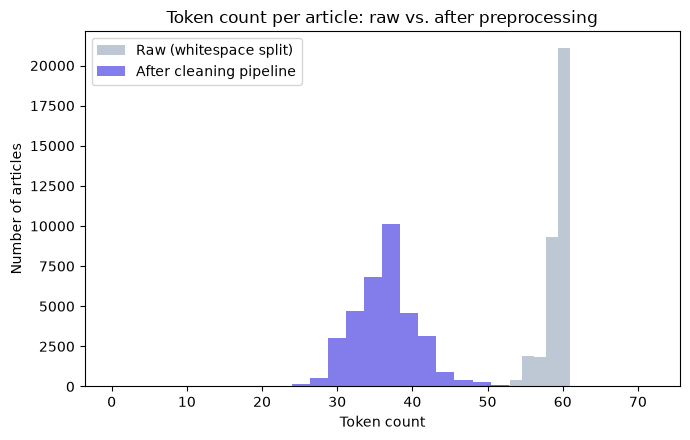

In [20]:
plt.figure(figsize=(7, 4.5))
plt.hist(raw_word_counts.clip(upper=100), bins=30, alpha=0.6, label="Raw (whitespace split)", color="#94a3b8")
plt.hist(clean_token_counts.clip(upper=100), bins=30, alpha=0.7, label="After cleaning pipeline", color="#4f46e5")
plt.legend()
plt.title("Token count per article: raw vs. after preprocessing")
plt.xlabel("Token count")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

## 6. Top tokens after cleaning — and a known limitation

A first bug here: the Devanagari danda (।) survived tokenization as its
own "token" and dominated frequency counts (97,120 occurrences) because
punctuation inside the Devanagari Unicode block isn't a stopword. Fixed
in `preprocessing.py` by explicitly excluding danda/double-danda at the
Fixed in `preprocessing.py` by explicitly excluding danda/double-danda at
the token stage — note this also removes it from `clean_text` (they're
built from the same filtered token list), so any future sentence-boundary
work should split on danda in the *raw* column, before this pipeline
runs.

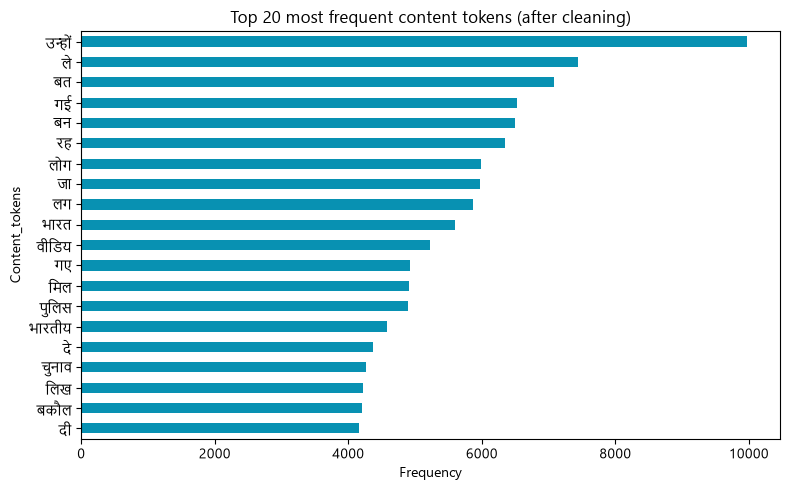

In [24]:
top20 = clean_df["Content_tokens"].explode().value_counts().head(20)
plt.figure(figsize=(8, 5))
top20.sort_values().plot(kind="barh", color="#0891b2")
plt.title("Top 20 most frequent content tokens (after cleaning)")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

**Remaining limitation, worth flagging honestly:** several of these top
tokens (`उन्हों`, `ले`, `बत`, `गई`, `बन`, `रह`, `जा`, `लग`, `दे`, `दी`) are
grammatical/functional words, not content words — but they aren't in our
225-word stopword list. Two causes:

1. **Spelling-variant gap** — the stopwords-iso list uses some
   anusvāra-based spellings (e.g. `उंहों`) that don't match the modern
   spelling used in this corpus (`उन्हों`, after stemming `उन्होंने`).
2. **Stemming creates new "stopword-shaped" stems** — light-stemming
   common verbs like `होना`/`देना`/`लिखना`/`बताना` produces short stems
   (`बन`, `दे`, `लिख`, `बत`) that were never in the original word-level
   stopword list because it was built for un-stemmed text.

**Decision carried to Module 4 (Feature Engineering):** rather than
hand-patch the stopword list indefinitely, build a small *corpus-derived*
stopword extension — the highest-document-frequency stemmed tokens above
some threshold — and apply it as a second pass specific to this dataset.
TF-IDF weighting will also naturally downweight these regardless.

## 7. Summary & decisions carried into later modules

| Finding | Decision for later modules |
|---|---|
| NLTK has no Hindi stopwords/tokenizer support | Use IndicNLP + a dedicated Hindi stopword list throughout |
| IndicNLP's normalizer corrupts colons into visarga if run before punctuation stripping | Pipeline order fixed: strip URLs/punctuation **first**, normalize second |
| Danda (।) survives as a token and dominates frequency counts | Explicitly excluded from both `tokens` and `clean_text` (same filtered list) — split raw text on danda instead, if sentence boundaries are ever needed |
| Full pipeline runs in ~9s for 34,826 rows × 2 columns | Fast enough to rerun freely; no need to sample for dev |
| Avg token count drops ~38.5% after cleaning (59.1 → 36.3) | Feature engineering (Module 4) can expect meaningfully shorter, denser token lists |
| Content vocabulary: 37,818 unique tokens | Informs TF-IDF `max_features` / vector size choices in Module 4 |
| Stopword list has spelling-variant + stemmed-form coverage gaps | Add a corpus-derived high-document-frequency stopword extension in Module 4 |

Every row now has `Headline_clean`, `Headline_tokens`, `Content_clean`,
`Content_tokens` ready to feed into Module 4 (Feature Engineering: TF-IDF
/ BoW / n-grams) and Module 5 (Word2Vec / FastText, which need the raw
`_tokens` lists).